# Data reading and exploratory analysis


## Imports


In [47]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "1_data_reading_EDA"
OUTPUT_FILE = RESULTS_DIR / "loaded_data.pkl"


In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Conversion factor

Test.Lab stores the signals in m/s² and the factor to `g` (1/9.80665) in `y_values.quantity.unit_transformation.factor`; the factor is read from every file and checked.

In [6]:
G_STANDARD = 9.80665  # m/s^2; the Test.Lab factor to g is 1/G_STANDARD


def acceleration_factor_to_g(signal):
    """Display factor stored by Test.Lab: raw MKS value * factor = value in g."""
    quantity = signal.y_values.quantity
    if str(quantity.label) != "g":
        raise ValueError(f"Unexpected acceleration unit label: {quantity.label!r}")
    factor = float(quantity.unit_transformation.factor)
    if not np.isclose(factor, 1.0 / G_STANDARD, rtol=1e-6):
        raise ValueError(f"Unexpected unit factor {factor!r}; expected 1/{G_STANDARD}")
    return factor


## Read the data


In [7]:
def read_time_signal(data):
    signal = data["Signal"]
    acceleration = np.asarray(signal.y_values.values).squeeze()
    acceleration = acceleration * acceleration_factor_to_g(signal)
    start_time = float(signal.x_values.start_value)
    time_step = float(signal.x_values.increment)
    number_of_points = int(signal.x_values.number_of_values)
    time = start_time + np.arange(number_of_points) * time_step
    return (acceleration, time)


In [8]:
mat_files = sorted(DATA_DIR.rglob("*.mat"))
print(f"Data folder: {DATA_DIR.resolve()}")
print(f"MAT files found: {len(mat_files)}")


Data folder: C:\Users\bruno\Downloads\BEPE (2)\BEPE\data\raw
MAT files found: 20


In [9]:
raw_data = {}
for path in mat_files:
    loaded_data = loadmat(path, squeeze_me=True, struct_as_record=False)
    visible_data = {}
    for name, value in loaded_data.items():
        if not name.startswith("__"):
            visible_data[name] = value
    raw_data[path.stem] = visible_data


In [10]:
FRF = {}
for file_name, data in raw_data.items():
    if file_name.startswith("FRF_ponta-base"):
        FRF[file_name] = data["FRF"]
print(f"FRF files: {len(FRF)}")


FRF files: 10


In [11]:
time_base = {}
time_axis = {}
for file_name, data in raw_data.items():
    if file_name.startswith("time_base"):
        acceleration, time = read_time_signal(data)
        time_base[file_name] = acceleration
        time_axis[file_name] = time
print(f"Base time files: {len(time_base)}")


Base time files: 5


In [12]:
time_tip = {}
for file_name, data in raw_data.items():
    if file_name.startswith("time_ponta"):
        acceleration, time = read_time_signal(data)
        time_tip[file_name] = acceleration
        time_axis[file_name] = time
print(f"Tip time files: {len(time_tip)}")


Tip time files: 5


## Split sweeps

Each file holds an upward sweep (50 → 150 Hz) followed by a downward sweep of equal length (~1003 s each, ~0.1 Hz/s); the record is split at its midpoint.

In [13]:
def split_half(values):
    values = np.asarray(values).squeeze()
    middle = values.shape[0] // 2
    first_half = values[:middle]
    second_half = values[middle:]
    return (first_half, second_half)


In [14]:
time_base_split = {}
time_axis_split = {}
for file_name, acceleration in time_base.items():
    sweep_up, sweep_down = split_half(acceleration)
    time_up, time_down = split_half(time_axis[file_name])
    up_name = f"{file_name}__sweep_up"
    down_name = f"{file_name}__sweep_down"
    time_base_split[up_name] = sweep_up
    time_base_split[down_name] = sweep_down
    time_axis_split[up_name] = time_up
    time_axis_split[down_name] = time_down
print(f"Split base signals: {len(time_base_split)}")


Split base signals: 10


In [15]:
time_tip_split = {}
for file_name, acceleration in time_tip.items():
    sweep_up, sweep_down = split_half(acceleration)
    time_up, time_down = split_half(time_axis[file_name])
    up_name = f"{file_name}__sweep_up"
    down_name = f"{file_name}__sweep_down"
    time_tip_split[up_name] = sweep_up
    time_tip_split[down_name] = sweep_down
    time_axis_split[up_name] = time_up
    time_axis_split[down_name] = time_down
print(f"Split tip signals: {len(time_tip_split)}")


Split tip signals: 10


## Parameters stored in file names


In [16]:
def parse_test_parameters(file_name):
    name_parts = file_name.split("_")
    current_mA = None
    amplitude_mg = None
    for part in name_parts:
        if part.endswith("mA"):
            current_mA = float(part.removesuffix("mA"))
        if part.endswith("mg"):
            amplitude_mg = float(part.removesuffix("mg"))
    frequency_limits = None
    if "Hz" in name_parts:
        hz_position = name_parts.index("Hz")
        limits = name_parts[hz_position - 1].split("-", maxsplit=1)
        if len(limits) == 2:
            frequency_limits = (float(limits[0]), float(limits[1]))
    sweep = None
    for part in name_parts:
        if part in ["sweep-up", "sweep-down", "sweep-up-down"]:
            sweep = part
            break
    required_values = [current_mA, amplitude_mg, frequency_limits, sweep]
    if any((value is None for value in required_values)):
        return None
    minimum_frequency, maximum_frequency = frequency_limits
    return {
        "current_mA": current_mA,
        "excitation_amplitude_mg": amplitude_mg,
        "freq_min_Hz": minimum_frequency,
        "freq_max_Hz": maximum_frequency,
        "sweep": sweep,
        "current_A": current_mA / 1000.0,
        "excitation_amplitude_g": amplitude_mg / 1000.0,
        "freq_bandwidth_Hz": maximum_frequency - minimum_frequency,
    }


In [17]:
test_parameters = {}
for file_name in sorted(raw_data):
    parameters = parse_test_parameters(file_name)
    if parameters is not None:
        test_parameters[file_name] = parameters
print("Test parameter summary")
print("=" * 80)
print(f"Files with test parameters: {len(test_parameters)}")


Test parameter summary
Files with test parameters: 20


In [18]:
excitation_amplitudes_mg = sorted({p["excitation_amplitude_mg"] for p in test_parameters.values()})
currents_mA = sorted({p["current_mA"] for p in test_parameters.values()})
frequency_ranges = sorted({(p["freq_min_Hz"], p["freq_max_Hz"]) for p in test_parameters.values()})
sweeps = sorted({p["sweep"] for p in test_parameters.values()})


In [19]:
if test_parameters:
    excitation_amplitudes_g = []
    for amplitude in excitation_amplitudes_mg:
        excitation_amplitudes_g.append(amplitude / 1000.0)
    currents_A = []
    for current in currents_mA:
        currents_A.append(current / 1000.0)
    print()
    print("Unique values found:")
    print(f"  excitation amplitudes: {excitation_amplitudes_mg} mg")
    print(f"  excitation amplitudes: {excitation_amplitudes_g} g")
    print(f"  currents: {currents_mA} mA")
    print(f"  currents: {currents_A} A")
    print(f"  frequency ranges: {frequency_ranges} Hz")
    print(f"  sweep types: {sweeps}")



Unique values found:
  excitation amplitudes: [500.0, 1000.0, 1500.0, 2000.0, 2500.0] mg
  excitation amplitudes: [0.5, 1.0, 1.5, 2.0, 2.5] g
  currents: [0.0] mA
  currents: [0.0] A
  frequency ranges: [(50.0, 150.0)] Hz
  sweep types: ['sweep-down', 'sweep-up', 'sweep-up-down']


In [20]:
processed_data = {
    "FRF": FRF,
    "time_base_split": time_base_split,
    "time_tip_split": time_tip_split,
    "time_axis_split": time_axis_split,
}

## Exploratory data analysis


In [21]:
expected_tip_keys = set()
for base_name in time_base_split:
    expected_tip_keys.add(base_name.replace("time_base", "time_ponta", 1))
actual_tip_keys = set(time_tip_split)
missing_tip = sorted(expected_tip_keys - actual_tip_keys)
extra_tip = sorted(actual_tip_keys - expected_tip_keys)


In [22]:
print("Exploratory data analysis")
print("=" * 80)
print("\nPair consistency")
print(f"  base split signals: {len(time_base_split)}")
print(f"  tip split signals: {len(time_tip_split)}")
print(f"  missing tip pairs: {len(missing_tip)}")
print(f"  extra tip signals: {len(extra_tip)}")
if missing_tip:
    print("  missing tip keys:")
    for file_name in missing_tip:
        print(f"    {file_name}")
if extra_tip:
    print("  extra tip keys:")
    for file_name in extra_tip:
        print(f"    {file_name}")


Exploratory data analysis

Pair consistency
  base split signals: 10
  tip split signals: 10
  missing tip pairs: 0
  extra tip signals: 0


In [23]:
def summarize_time_axis(time):
    time = np.asarray(time).squeeze()
    time_difference = np.diff(time)
    time_step = float(np.nanmedian(time_difference))
    time_step_deviation = float(np.nanstd(time_difference))
    sampling_frequency = 1.0 / time_step if time_step > 0 else np.nan
    duration = float(time[-1] - time[0])
    summary = {
        "n": int(time.size),
        "duration_s": duration,
        "dt_s": time_step,
        "dt_std_s": time_step_deviation,
        "fs_Hz": float(sampling_frequency),
    }
    return summary


In [24]:
time_summaries = {}
for file_name, time in time_axis_split.items():
    if np.asarray(time).size > 1:
        time_summaries[file_name] = summarize_time_axis(time)


In [25]:
print("\nTime vector summary")
if time_summaries:
    time_steps = set()
    sampling_frequencies = set()
    durations = []
    for summary in time_summaries.values():
        time_steps.add(round(summary["dt_s"], 12))
        sampling_frequencies.add(round(summary["fs_Hz"], 6))
        durations.append(summary["duration_s"])
    print(f"  unique dt values: {sorted(time_steps)} s")
    print(f"  unique sampling frequencies: {sorted(sampling_frequencies)} Hz")
    print(f"  duration range: {min(durations):.6g} to {max(durations):.6g} s")



Time vector summary
  unique dt values: [0.0025] s
  unique sampling frequencies: [400.0] Hz
  duration range: 1003.44 to 1003.52 s


In [26]:
paired_signals = {}
for base_name in sorted(time_base_split):
    tip_name = base_name.replace("time_base", "time_ponta", 1)
    if tip_name not in time_tip_split:
        continue
    time = np.asarray(time_axis_split[base_name]).squeeze()
    base = np.asarray(time_base_split[base_name]).squeeze()
    tip = np.asarray(time_tip_split[tip_name]).squeeze()
    if len({time.size, base.size, tip.size}) != 1:
        raise ValueError(f"Mismatched base/tip lengths: {base_name}")
    if not np.array_equal(time, np.asarray(time_axis_split[tip_name]).squeeze()):
        raise ValueError(f"Mismatched base/tip timestamps: {base_name}")
    number_of_points = time.size
    time = time[:number_of_points]
    base = base[:number_of_points]
    tip = tip[:number_of_points]
    if base_name.endswith("__sweep_up"):
        split_sweep = "sweep_up"
    elif base_name.endswith("__sweep_down"):
        split_sweep = "sweep_down"
    else:
        split_sweep = "combined"
    paired_signals[base_name] = {
        "time": time,
        "base": base,
        "tip": tip,
        "relative": tip - base,
        "parameters": parse_test_parameters(base_name) or {},
        "split_sweep": split_sweep,
    }


In [27]:
relative_acceleration = {}
for base_name, test in paired_signals.items():
    relative_name = base_name.replace("time_base", "relative_acceleration", 1)
    relative_acceleration[relative_name] = test["relative"]


### Signal metrics


In [28]:
def summarize_signal(values):
    values = np.asarray(values).squeeze()
    finite_values = values[np.isfinite(values)]
    summary = {
        "mean": np.nan,
        "rms": np.nan,
        "peak_abs": np.nan,
        "peak_to_peak": np.nan,
        "nan_count": int(np.isnan(values).sum()),
        "inf_count": int(np.isinf(values).sum()),
    }
    if finite_values.size == 0:
        return summary
    summary["mean"] = float(np.nanmean(values))
    summary["rms"] = float(np.sqrt(np.nanmean(values**2)))
    summary["peak_abs"] = float(np.nanmax(np.abs(values)))
    summary["peak_to_peak"] = float(np.nanmax(values) - np.nanmin(values))
    return summary


In [29]:
signal_summaries = {}
for base_name, test in paired_signals.items():
    summaries = {
        "base": summarize_signal(test["base"]),
        "tip": summarize_signal(test["tip"]),
        "relative": summarize_signal(test["relative"]),
    }
    signal_summaries[base_name] = summaries


In [30]:
frequency_summaries = {}
for base_name, test in paired_signals.items():
    parameters = test["parameters"]
    band_start = parameters.get("freq_min_Hz", 50.0)
    band_end = parameters.get("freq_max_Hz", 150.0)
    values = np.asarray(test["relative"]).squeeze()
    time = np.asarray(test["time"]).squeeze()
    summary = {
        "dominant_freq_Hz": np.nan,
        "band_peak_freq_Hz": np.nan,
        "band_energy_fraction": np.nan,
    }
    if values.size != time.size:
        raise ValueError(f"Mismatched signal/time lengths: {base_name}")
    number_of_points = values.size
    if number_of_points >= 4:
        values = values - np.nanmean(values)
        time_step = float(np.nanmedian(np.diff(time)))
        if np.isfinite(time_step) and time_step > 0:
            window = np.hanning(number_of_points)
            spectrum = np.fft.rfft(values * window)
            frequencies = np.fft.rfftfreq(number_of_points, d=time_step)
            power = np.abs(spectrum) ** 2
            positive = frequencies > 0
            if power.size > 1 and np.nansum(power[1:]) != 0:
                positive_frequencies = frequencies[positive]
                positive_power = power[positive]
                dominant_position = np.argmax(positive_power)
                summary["dominant_freq_Hz"] = float(positive_frequencies[dominant_position])
                inside_band = (frequencies >= band_start) & (frequencies <= band_end)
                if np.any(inside_band):
                    band_frequencies = frequencies[inside_band]
                    band_power = power[inside_band]
                    band_peak_position = np.argmax(band_power)
                    summary["band_peak_freq_Hz"] = float(band_frequencies[band_peak_position])
                    summary["band_energy_fraction"] = float(
                        np.nansum(band_power) / np.nansum(positive_power)
                    )
    frequency_summaries[base_name] = summary


In [31]:
rows_by_name = {}
for base_name, test in paired_signals.items():
    parameters = test["parameters"]
    time_summary = summarize_time_axis(test["time"])
    summaries = signal_summaries[base_name]
    base_summary = summaries["base"]
    tip_summary = summaries["tip"]
    relative_summary = summaries["relative"]
    frequency = frequency_summaries[base_name]
    row = {
        "key": base_name,
        "excitation_amplitude_mg": parameters.get("excitation_amplitude_mg", np.nan),
        "current_mA": parameters.get("current_mA", np.nan),
        "split_sweep": test["split_sweep"],
        "n": int(test["time"].size),
        "duration_s": time_summary["duration_s"],
        "dt_s": time_summary["dt_s"],
        "fs_Hz": time_summary["fs_Hz"],
        "base_mean_g": base_summary["mean"],
        "tip_mean_g": tip_summary["mean"],
        "rel_mean_g": relative_summary["mean"],
        "base_rms_g": base_summary["rms"],
        "tip_rms_g": tip_summary["rms"],
        "rel_rms_g": relative_summary["rms"],
        "base_peak_g": base_summary["peak_abs"],
        "tip_peak_g": tip_summary["peak_abs"],
        "rel_peak_g": relative_summary["peak_abs"],
        "base_pp_g": base_summary["peak_to_peak"],
        "tip_pp_g": tip_summary["peak_to_peak"],
        "rel_pp_g": relative_summary["peak_to_peak"],
        "rel_dominant_freq_Hz": frequency["dominant_freq_Hz"],
        "rel_band_peak_freq_Hz": frequency["band_peak_freq_Hz"],
        "rel_band_energy_fraction": frequency["band_energy_fraction"],
        "nan_count_total": base_summary["nan_count"] + tip_summary["nan_count"],
        "inf_count_total": base_summary["inf_count"] + tip_summary["inf_count"],
    }
    rows_by_name[base_name] = row
exploratory_rows = list(rows_by_name.values())


In [32]:
print("\nSignal and relative-acceleration metrics")
print(f"  analyzed paired split tests: {len(exploratory_rows)}")
header = "ampl_mg sweep       n      duration_s  base_rms_g  tip_rms_g   rel_rms_g   rel_peak_g   band_energy"
print(header)
print("-" * len(header))
for row in exploratory_rows:
    print(
        f"{row['excitation_amplitude_mg']:7.0f} {row['split_sweep']:<10} {row['n']:7d} {row['duration_s']:11.4f} {row['base_rms_g']:11.4g} {row['tip_rms_g']:10.4g} {row['rel_rms_g']:11.4g} {row['rel_peak_g']:11.4g} {row['rel_band_energy_fraction']:11.4g}"
    )



Signal and relative-acceleration metrics
  analyzed paired split tests: 10
ampl_mg sweep       n      duration_s  base_rms_g  tip_rms_g   rel_rms_g   rel_peak_g   band_energy
---------------------------------------------------------------------------------------------------
   1000 sweep_down  401377   1003.4400      0.7065      3.968       4.066       20.34      0.9994
   1000 sweep_up    401376   1003.4375      0.7071      3.812        3.91       20.36      0.9995
   1500 sweep_down  401377   1003.4400       1.059      5.952       6.122       31.19      0.9984
   1500 sweep_up    401376   1003.4375       1.061      5.651       5.839       31.09      0.9985
   2000 sweep_down  401408   1003.5175       1.412      7.664       7.917        38.9      0.9973
   2000 sweep_up    401408   1003.5175       1.414      7.338       7.608       38.76      0.9975
   2500 sweep_down  401377   1003.4400       1.765      9.227       9.546       45.92      0.9962
   2500 sweep_up    401376   1003.4375

### Offsets


In [33]:
def offset_to_rms(mean, rms):
    if rms == 0:
        return np.nan
    return abs(mean) / rms


In [34]:
print("\nOffset check")
print("  Offset is the signal mean. Large acceleration offset can create drift during integration.")
offset_header = "ampl_mg sweep       base_mean_g   tip_mean_g    rel_mean_g    base_offset/RMS  tip_offset/RMS   rel_offset/RMS"
print(offset_header)
print("-" * len(offset_header))
for row in exploratory_rows:
    base_ratio = offset_to_rms(row["base_mean_g"], row["base_rms_g"])
    tip_ratio = offset_to_rms(row["tip_mean_g"], row["tip_rms_g"])
    relative_ratio = offset_to_rms(row["rel_mean_g"], row["rel_rms_g"])
    print(
        f"{row['excitation_amplitude_mg']:7.0f} {row['split_sweep']:<10} {row['base_mean_g']:12.4g} {row['tip_mean_g']:12.4g} {row['rel_mean_g']:12.4g} {base_ratio:15.4g} {tip_ratio:15.4g} {relative_ratio:15.4g}"
    )



Offset check
  Offset is the signal mean. Large acceleration offset can create drift during integration.
ampl_mg sweep       base_mean_g   tip_mean_g    rel_mean_g    base_offset/RMS  tip_offset/RMS   rel_offset/RMS
--------------------------------------------------------------------------------------------------------------
   1000 sweep_down   -6.862e-06   -3.024e-06    3.838e-06       9.713e-06       7.621e-07       9.438e-07
   1000 sweep_up     -7.698e-07    8.307e-07      1.6e-06       1.089e-06       2.179e-07       4.094e-07
   1500 sweep_down    2.081e-06    -4.25e-07   -2.506e-06       1.964e-06       7.141e-08       4.093e-07
   1500 sweep_up     -5.108e-07   -2.876e-07    2.232e-07       4.816e-07        5.09e-08       3.822e-08
   2000 sweep_down   -2.721e-06    8.716e-07    3.592e-06       1.927e-06       1.137e-07       4.537e-07
   2000 sweep_up      1.623e-06   -2.126e-06   -3.749e-06       1.147e-06       2.898e-07       4.928e-07
   2500 sweep_down    3.944e-06   -2

In [35]:
rows_by_sweep = {}
for row in exploratory_rows:
    sweep_name = row["split_sweep"]
    if sweep_name not in rows_by_sweep:
        rows_by_sweep[sweep_name] = []
    rows_by_sweep[sweep_name].append(row)
for sweep_name in rows_by_sweep:
    rows_by_sweep[sweep_name].sort(key=lambda row: row["excitation_amplitude_mg"])


### Offset and RMS plots


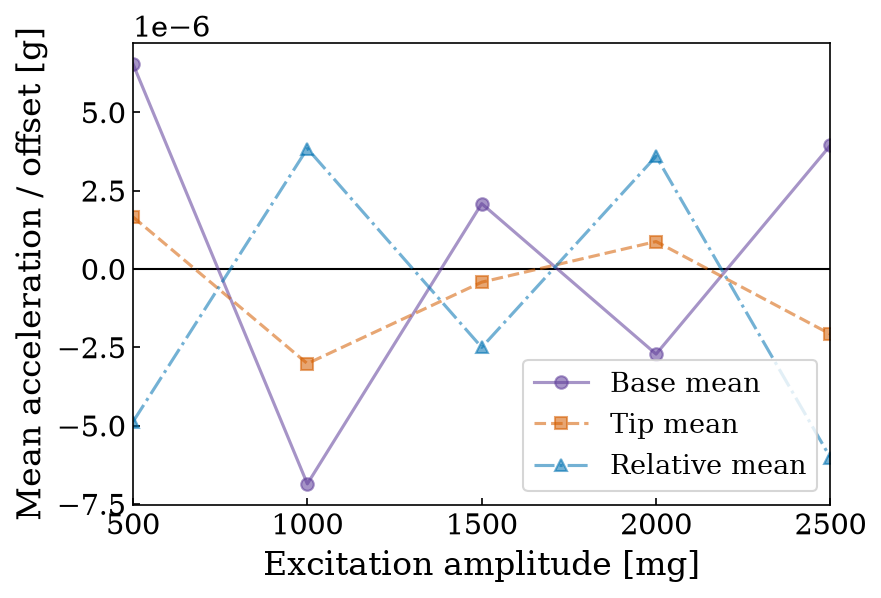

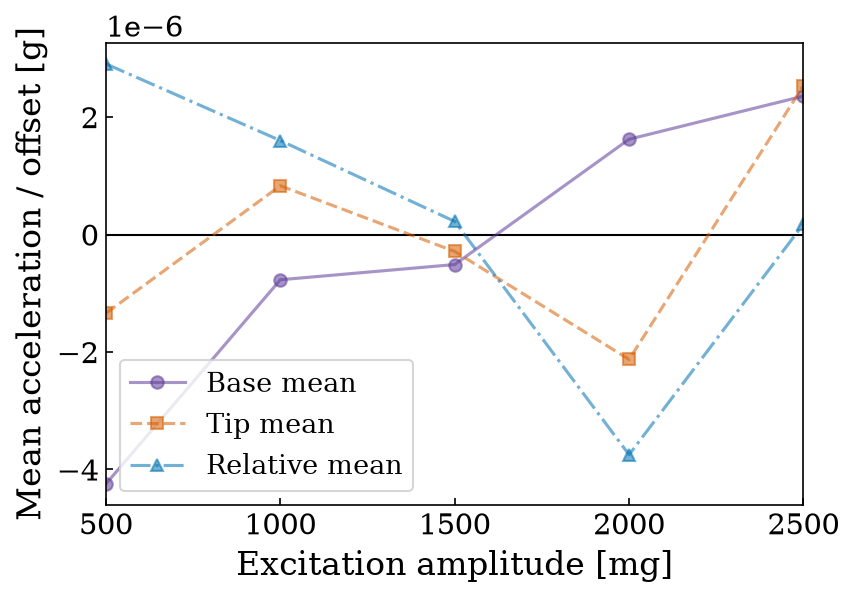

In [36]:
for sweep_name in sorted(rows_by_sweep):
    rows = rows_by_sweep[sweep_name]
    amplitudes = [row["excitation_amplitude_mg"] for row in rows]
    base_means = [row["base_mean_g"] for row in rows]
    tip_means = [row["tip_mean_g"] for row in rows]
    relative_means = [row["rel_mean_g"] for row in rows]
    plt.figure()
    plt.axhline(0.0, color="black", linewidth=1.0)
    plt.plot(amplitudes, base_means, "o-", color=COLORS["purple"], label="Base mean", alpha=0.55)
    plt.plot(
        amplitudes,
        tip_means,
        "s--",
        color=COLORS["orange"],
        label="Tip mean",
        alpha=0.55,
    )
    plt.plot(
        amplitudes,
        relative_means,
        "^-.",
        color=COLORS["blue"],
        label="Relative mean",
        alpha=0.55,
    )
    plt.xlabel("Excitation amplitude [mg]")
    plt.ylabel("Mean acceleration / offset [g]")
    plt.legend()
    figure = plt.gcf()
    file_name = f"eda_offset_{slug(sweep_name)}.pdf"
    figure.savefig(FIGURES_DIR / file_name, format="pdf")
    plt.show()


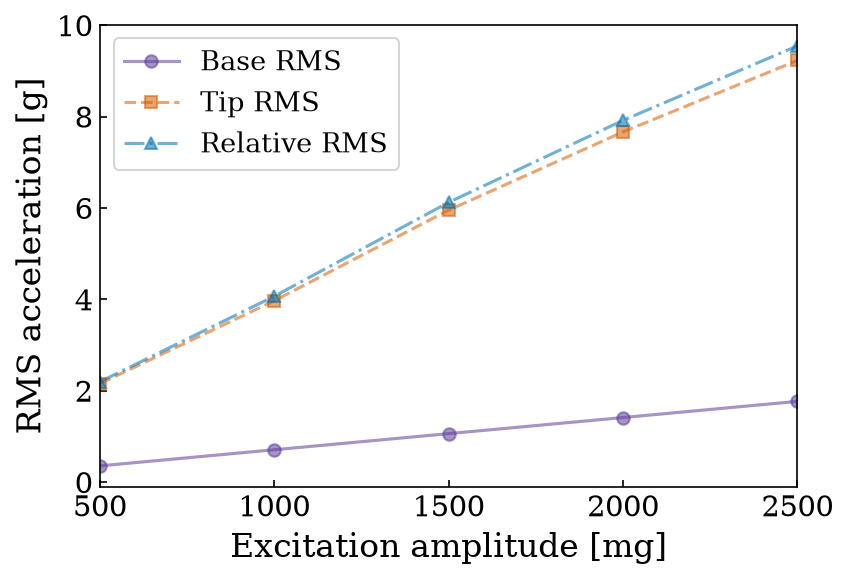

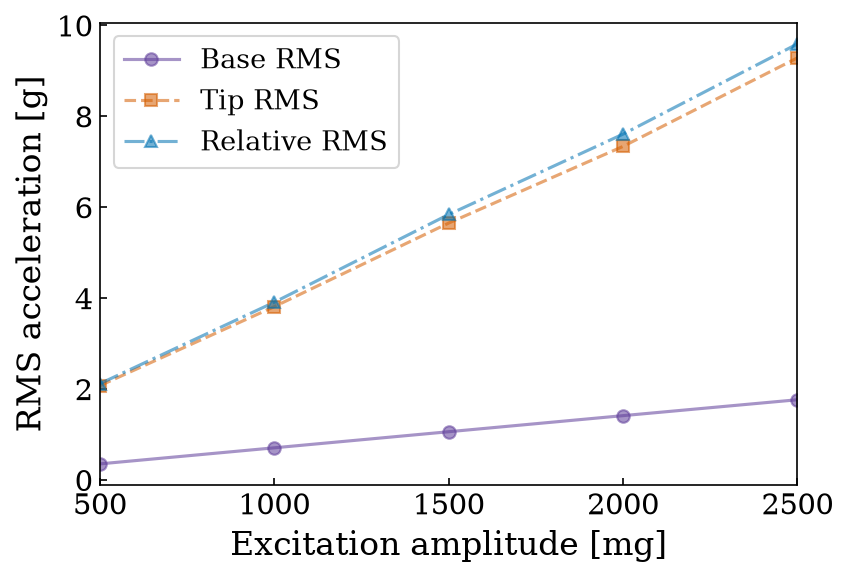

In [37]:
for sweep_name in sorted(rows_by_sweep):
    rows = rows_by_sweep[sweep_name]
    amplitudes = [row["excitation_amplitude_mg"] for row in rows]
    base_rms = [row["base_rms_g"] for row in rows]
    tip_rms = [row["tip_rms_g"] for row in rows]
    relative_rms = [row["rel_rms_g"] for row in rows]
    plt.figure()
    plt.plot(amplitudes, base_rms, "o-", color=COLORS["purple"], label="Base RMS", alpha=0.55)
    plt.plot(
        amplitudes, tip_rms, "s--", color=COLORS["orange"], label="Tip RMS", alpha=0.55
    )
    plt.plot(
        amplitudes,
        relative_rms,
        "^-.",
        color=COLORS["blue"],
        label="Relative RMS",
        alpha=0.55,
    )
    plt.xlabel("Excitation amplitude [mg]")
    plt.ylabel("RMS acceleration [g]")
    plt.legend()
    figure = plt.gcf()
    file_name = f"eda_rms_{slug(sweep_name)}.pdf"
    figure.savefig(FIGURES_DIR / file_name, format="pdf")
    plt.show()


In [38]:
processed_data["relative_acceleration"] = relative_acceleration

## Raw-data plots


In [39]:
frf_plot_data = {}
for file_name, frf in FRF.items():
    parameters = test_parameters.get(file_name)
    if parameters is None:
        raise ValueError(f"Could not find frequency range in file name: {file_name}")
    minimum_frequency = parameters["freq_min_Hz"]
    maximum_frequency = parameters["freq_max_Hz"]
    if hasattr(frf, "y_values") and hasattr(frf.y_values, "values"):
        response = np.asarray(frf.y_values.values).squeeze()
    elif hasattr(frf, "Data"):
        response = np.asarray(frf.Data).squeeze()
    else:
        raise AttributeError(f"Could not find FRF response data in: {file_name}")
    if response.ndim > 1:
        response = response[:, -1]
    frequency = None
    if hasattr(frf, "x_values"):
        x_values = frf.x_values
        if hasattr(x_values, "values"):
            frequency = np.asarray(x_values.values).squeeze()
        elif hasattr(x_values, "start_value"):
            start = float(x_values.start_value)
            step = float(x_values.increment)
            number_of_points = int(x_values.number_of_values)
            frequency = start + np.arange(number_of_points) * step
    if frequency is None or len(frequency) != len(response):
        frequency = np.linspace(minimum_frequency, maximum_frequency, len(response))
    magnitude = np.abs(response)
    peak_position = int(np.argmax(magnitude))
    frf_plot_data[file_name] = {
        "frequency": frequency,
        "response": response,
        "magnitude": magnitude,
        "peak_position": peak_position,
        "resonance_frequency": frequency[peak_position],
    }


### FRF resonance frequencies

In [40]:
for file_name, plot_data in frf_plot_data.items():
    print(f"{file_name}: resonance frequency = {plot_data['resonance_frequency']:.6g} Hz")

FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down: resonance frequency = 92.89 Hz
FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-up: resonance frequency = 92.35 Hz
FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-down: resonance frequency = 91.97 Hz
FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-up: resonance frequency = 91.51 Hz
FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-down: resonance frequency = 90.91 Hz
FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-up: resonance frequency = 90.72 Hz
FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-down: resonance frequency = 91.37 Hz
FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-up: resonance frequency = 91.91 Hz
FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-down: resonance frequency = 94.53 Hz
FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-up: resonance frequency = 94.64 Hz


### FRFs of every experiment


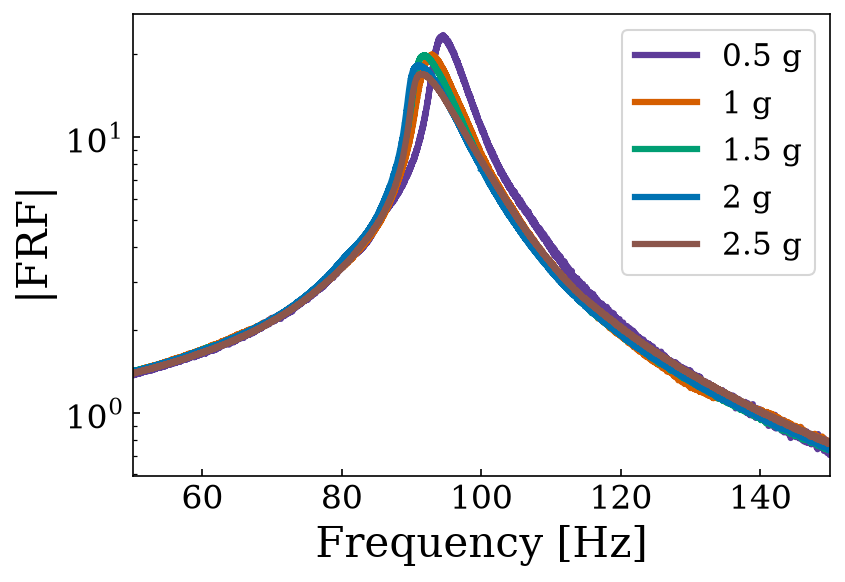

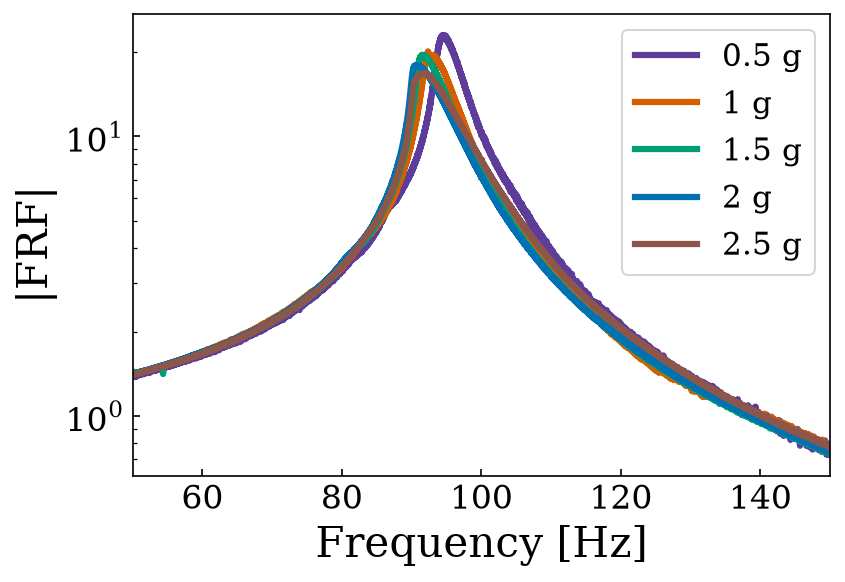

In [48]:
plot_color_order = plt.rcParams["axes.prop_cycle"].by_key()["color"]
frf_amplitudes = sorted({p["excitation_amplitude_mg"] for p in test_parameters.values()})
experiment_colors = dict(zip(frf_amplitudes, plot_color_order))
for sweep_name in ["sweep-down", "sweep-up"]:
    frf_names = [name for name in FRF if test_parameters[name]["sweep"] == sweep_name]
    frf_names.sort(key=lambda name: test_parameters[name]["excitation_amplitude_mg"])
    figure, axis = plt.subplots()
    for file_name in frf_names:
        parameters = test_parameters[file_name]
        plot_data = frf_plot_data[file_name]
        axis.semilogy(
            plot_data["frequency"],
            plot_data["magnitude"],
            color=experiment_colors[parameters["excitation_amplitude_mg"]],
            linewidth=3,
            label=f"{parameters['excitation_amplitude_g']:g} g",
        )
    axis.set_xlabel("Frequency [Hz]")
    axis.set_ylabel("|FRF|")
    axis.legend(ncol=1)
    figure.savefig(FIGURES_DIR / f"raw_frf_all_experiments_{slug(sweep_name)}.pdf", format="pdf")
    plt.show()

### Raw time signals


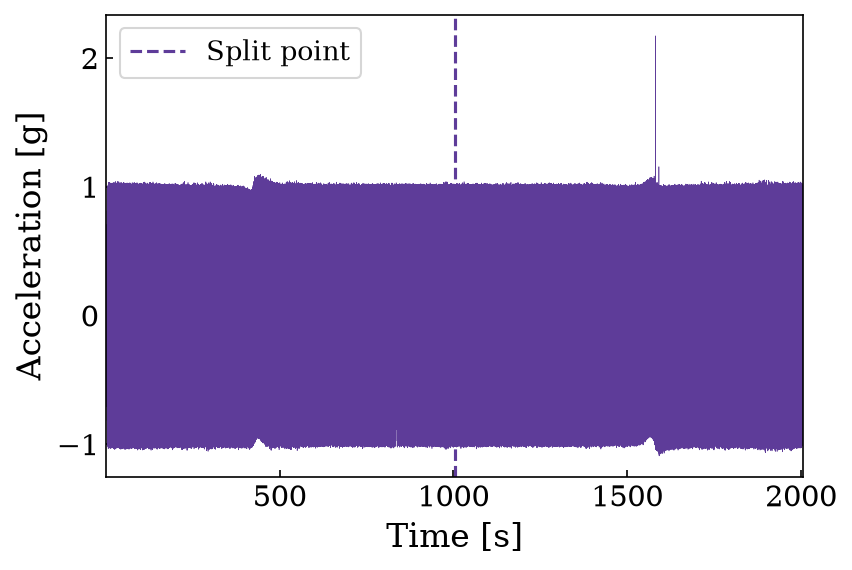

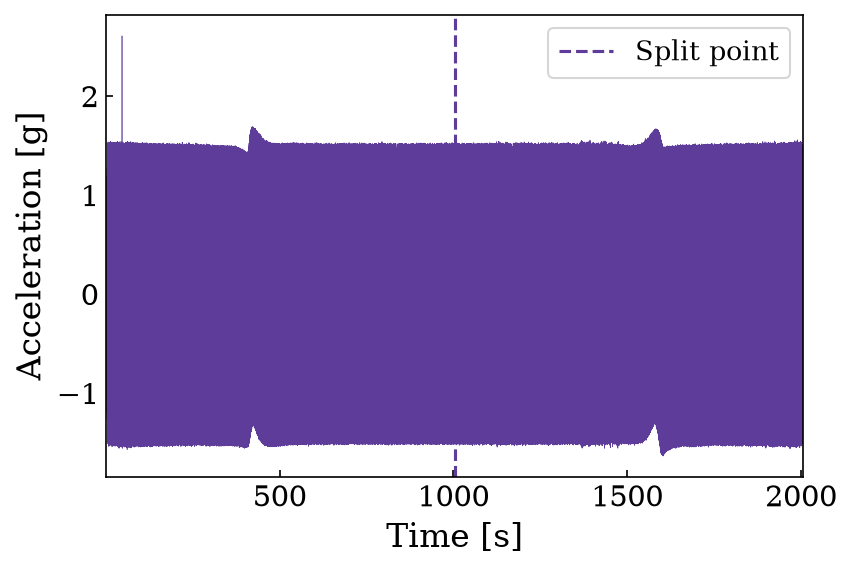

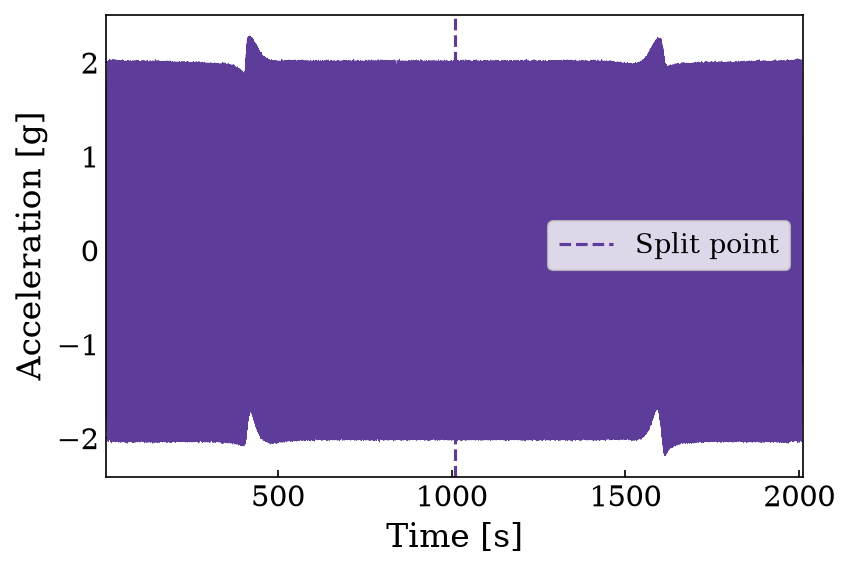

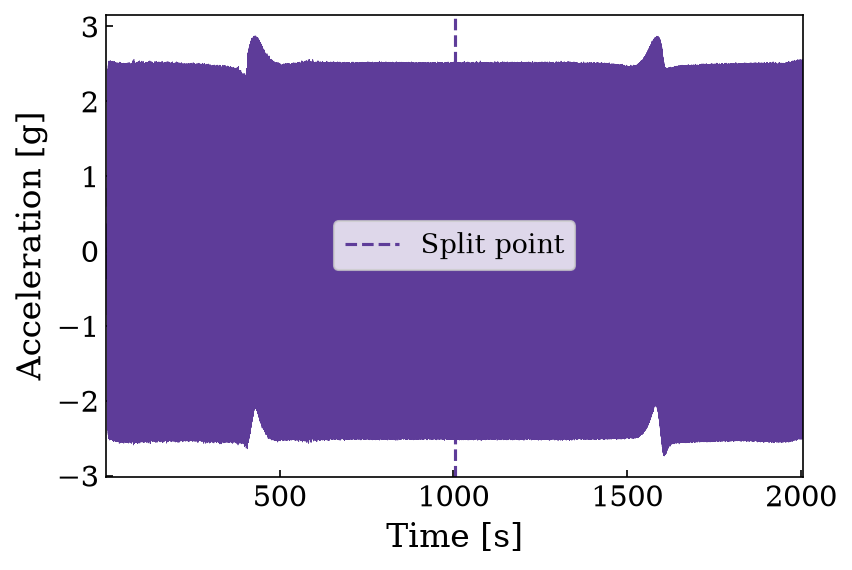

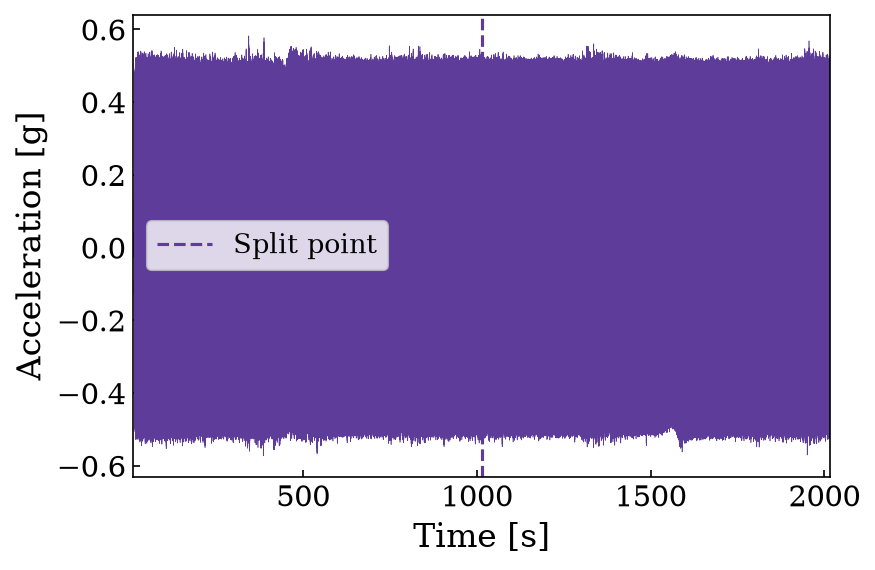

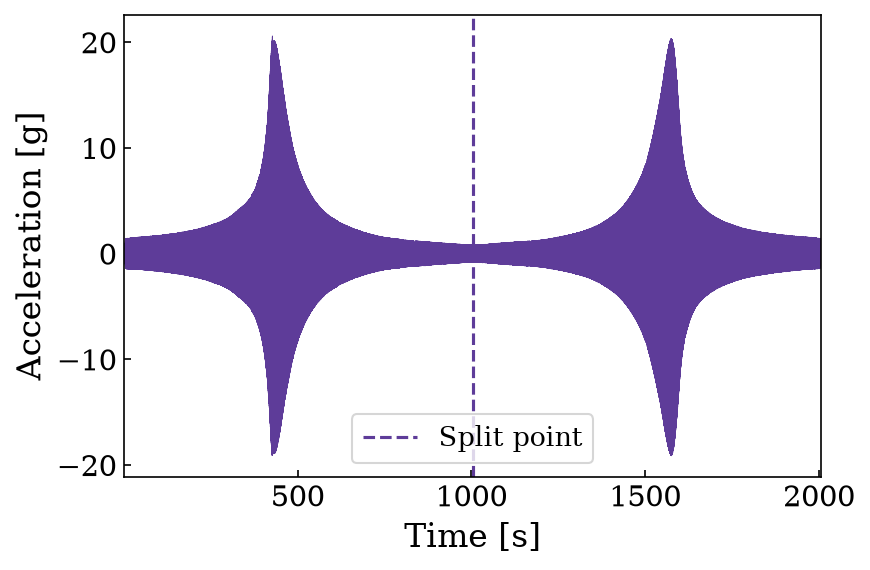

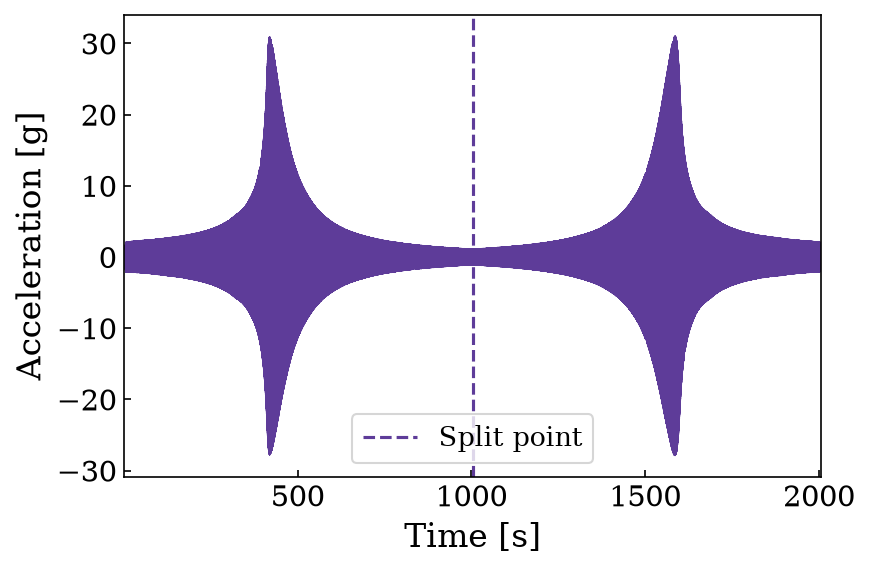

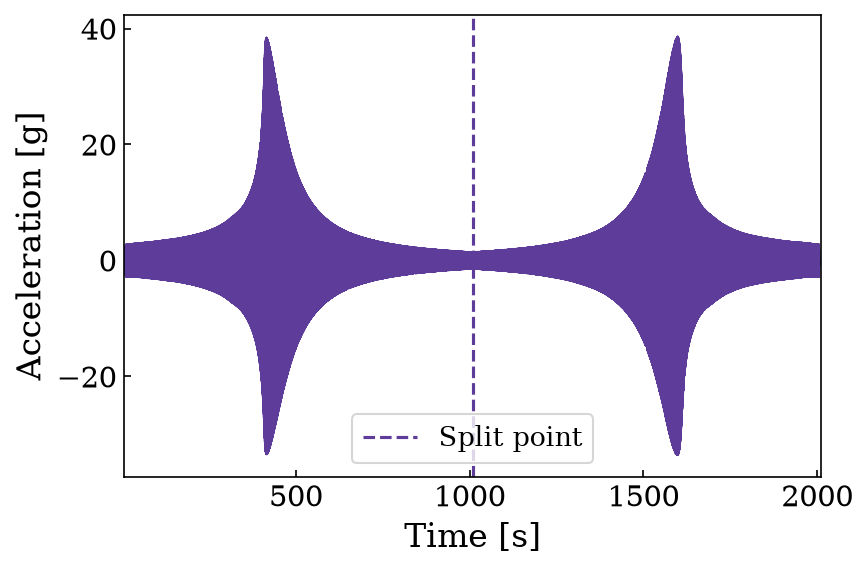

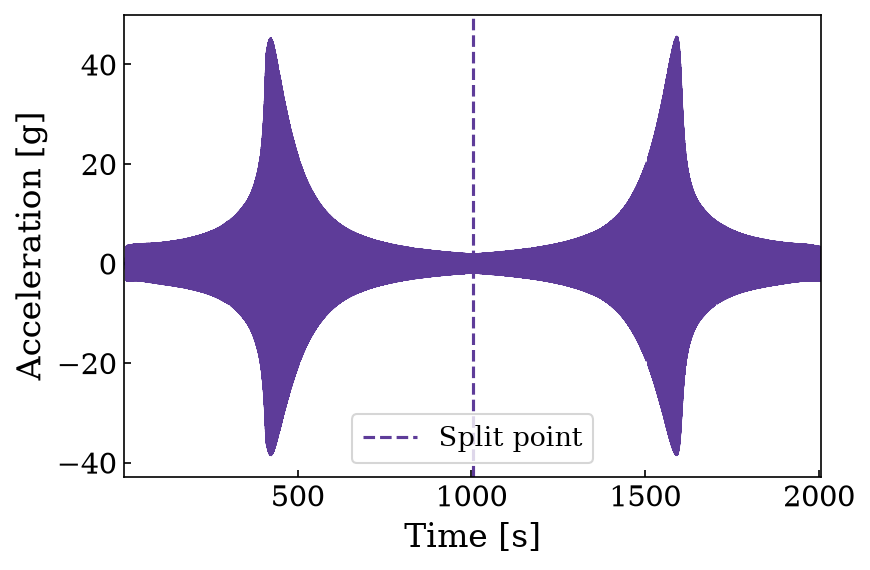

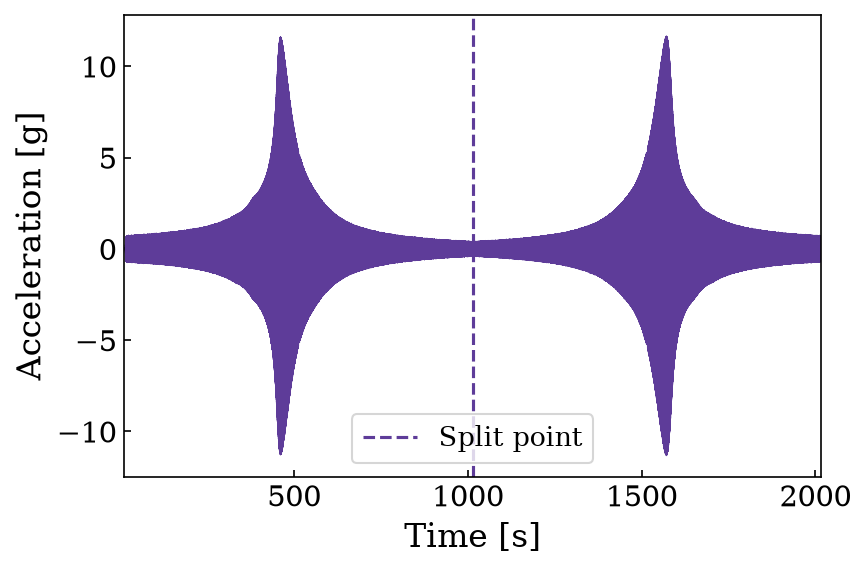

In [42]:
for record_name in sorted(time_base) + sorted(time_tip):
    acceleration = time_base.get(record_name, time_tip.get(record_name))
    time = time_axis[record_name]
    middle = len(time) // 2
    plt.figure()
    plt.plot(time, acceleration, color=COLORS["purple"], linewidth=0.3)
    plt.axvline(time[middle], color=COLORS["purple"], linestyle="--", label="Split point")
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration [g]")
    plt.legend()
    plt.gcf().savefig(FIGURES_DIR / f"raw_time_{slug(record_name)}.pdf", format="pdf")
    plt.show()

## Save the results


In [43]:
with open(OUTPUT_FILE, "wb") as file:
    pickle.dump(processed_data, file)
print(f"Saved: {OUTPUT_FILE}")


Saved: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\loaded_data.pkl
